In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# The 'churn analysis .csv' file was not found.
# Please upload the 'churn analysis .csv' file or provide the correct path.
# Example for uploading:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# Original line that caused the error:
# df=pd.read_csv('churn analysis .csv')

In [ ]:
df = pd.read_csv('/content/churn analysis .csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing blanks as 0 as tenure is 0 and no total charges are recorded
# **bold text**

In [ ]:
df['TotalCharges']=df['TotalCharges'].replace(" ",'0')
df['TotalCharges']=df['TotalCharges'].astype("float")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
def conv(value):
  if value==1:
    return "yes"
  else:
    return "no"

In [ ]:
df['SeniorCitizen']=df['SeniorCitizen'].apply(conv)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#convert 0 and 1 value of senior citizen to yes and no

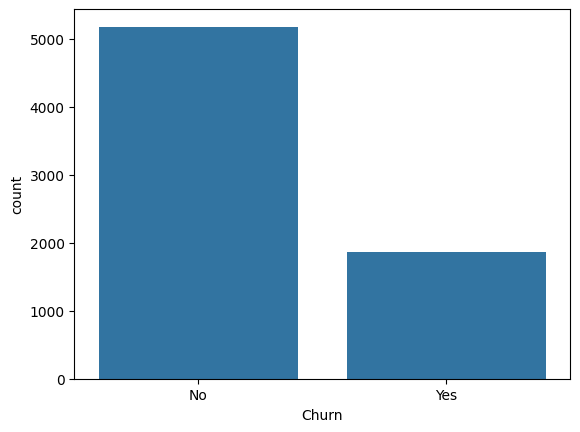

In [ ]:
sns.countplot(x='Churn',data=df)
plt.show()

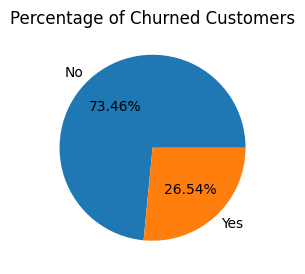

In [ ]:
plt.figure(figsize=(3,4))
gb = df['Churn'].value_counts() # Get counts of 'Yes' and 'No' in 'Churn' column
plt.pie(gb, labels=gb.index, autopct='%1.2f%%') # Use the counts directly for the pie chart
plt.title('Percentage of Churned Customers')
plt.show()

In [ ]:
#from the given pie chart we can figure out that 26.5% of customers have churned out
#now lets explore the reasons behind it

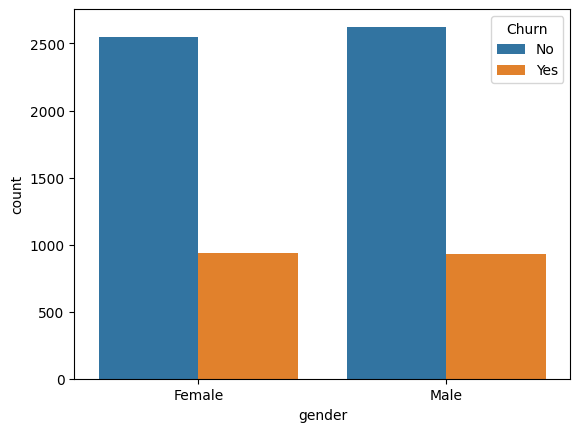

In [ ]:
sns.countplot(x='gender',data=df,hue='Churn')
plt.show()

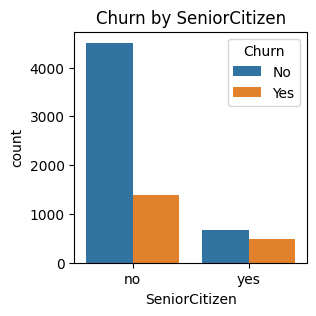

In [ ]:
plt.figure(figsize=(3,3))
sns.countplot(x = 'SeniorCitizen',data=df,hue='Churn')
plt.title("Churn by SeniorCitizen")
plt.show()

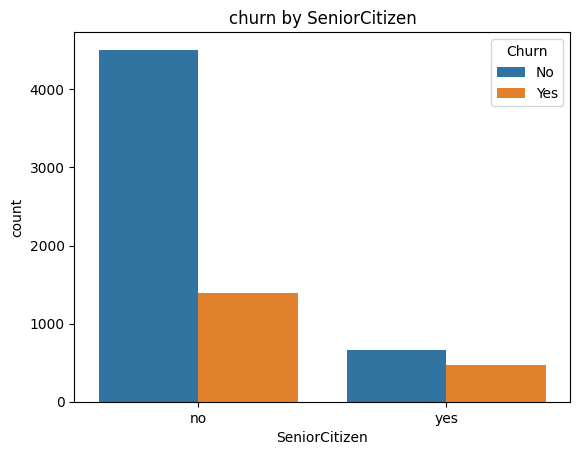

In [ ]:
sns.countplot(x='SeniorCitizen',data=df,hue='Churn')
plt.title('churn by SeniorCitizen')
plt.show()

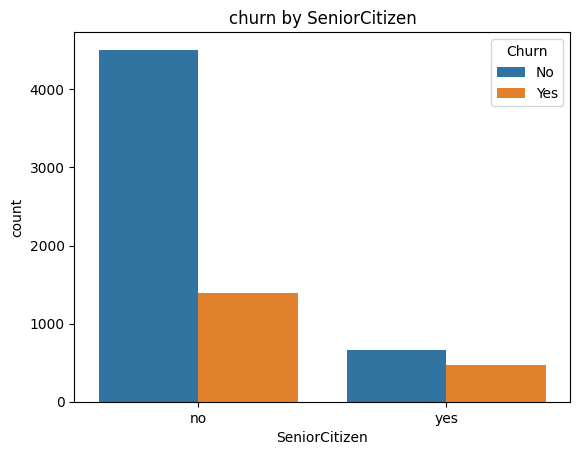

In [ ]:
sns.countplot(x='SeniorCitizen',data=df,hue='Churn')
plt.title('churn by SeniorCitizen')
plt.show()

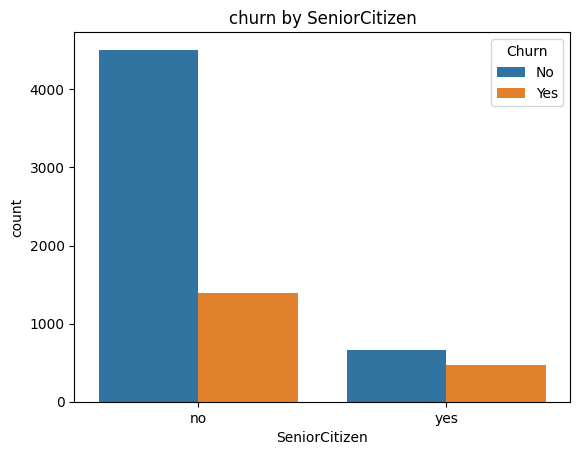

In [ ]:
sns.countplot(x='SeniorCitizen',data=df,hue='Churn')
plt.title('churn by SeniorCitizen')
plt.show()

File not found at '/content/churn analysis .csv'. Please upload the file.


Saving churn analysis .csv to churn analysis .csv


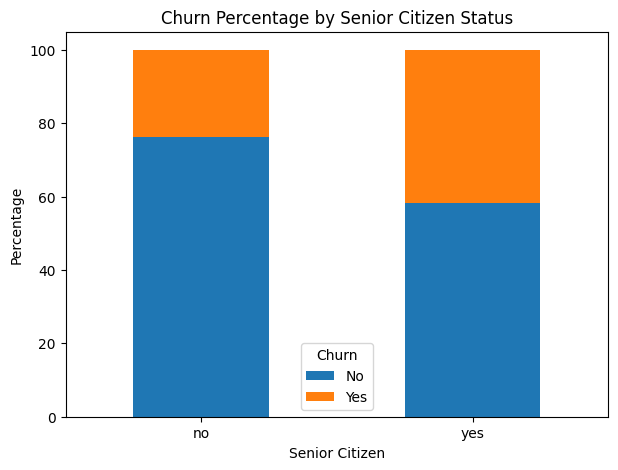

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

try:
    df = pd.read_csv('/content/churn analysis .csv')
except FileNotFoundError:
    print("File not found at '/content/churn analysis .csv'. Please upload the file.")
    uploaded = files.upload()
    if uploaded:
        file_name = list(uploaded.keys())[0]
        df = pd.read_csv(file_name)
    else:
        print("No file uploaded. Please ensure 'churn analysis .csv' is uploaded.")
        # Optionally re-raise error or handle as appropriate if no file was uploaded
        raise # Re-raise if no file was successfully read

# Preprocessing steps from previous cells to ensure df is correctly set up
df['TotalCharges'] = df['TotalCharges'].replace(" ",'0').astype("float")
def conv(value):
  if value==1:
    return "yes"
  else:
    return "no"
df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

churn_by_senior_citizen = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).mul(100).unstack()

churn_by_senior_citizen.plot(kind='bar', stacked=True, figsize=(7, 5))
plt.title('Churn Percentage by Senior Citizen Status')
plt.ylabel('Percentage')
plt.xlabel('Senior Citizen')
plt.xticks(rotation=0)
plt.show()

In [ ]:
#comparative version of people in senior citizen category have churned

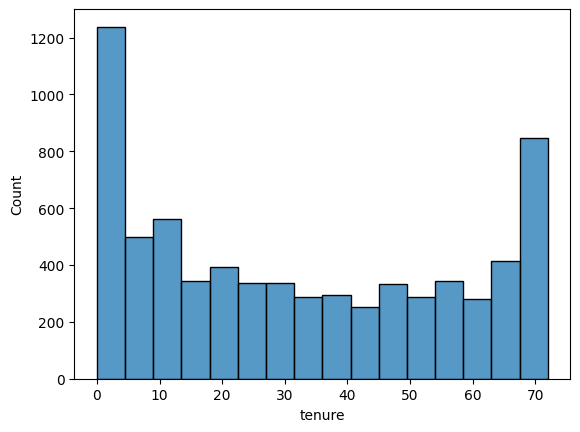

In [ ]:
import seaborn as sns
sns.histplot(x='tenure', data=df)
plt.show()

people who have used our services and stayes and people who used for a few months and churned


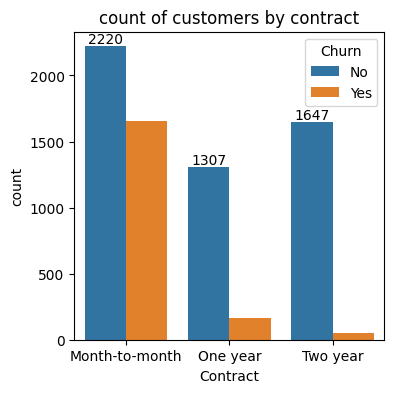

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded and preprocessed
try:
    df = pd.read_csv('/content/churn analysis .csv')
except FileNotFoundError:
    # This block handles cases where the file might not be in the default Colab path.
    # In an interactive session, 'files.upload()' would prompt the user.
    # For this automated context, we assume a previous successful upload or file existence.
    print("Warning: 'churn analysis .csv' not found at /content/. Please ensure it's uploaded or path is correct.")
    # Attempting to load from an existing 'df' if it was defined in another cell and kernel not reset.
    # Otherwise, this will raise a NameError if df is truly undefined.
    if 'df' not in locals() and 'df' not in globals():
        raise FileNotFoundError("DataFrame 'df' not found. Please ensure the 'churn analysis .csv' file is accessible and loaded.")

# Preprocessing steps for df
df['TotalCharges'] = df['TotalCharges'].replace(" ", '0').astype("float")
def conv(value):
  if value==1:
    return "yes"
  else:
    return "no"
df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

plt.figure(figsize=(4,4))
ax=sns.countplot(x='Contract',data=df,hue='Churn')
plt.bar_label(ax.containers[0])
plt.title('count of customers by contract')
plt.show()

people who have month to month contract are more likely to churn then those who have years worth of subscription


In [ ]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

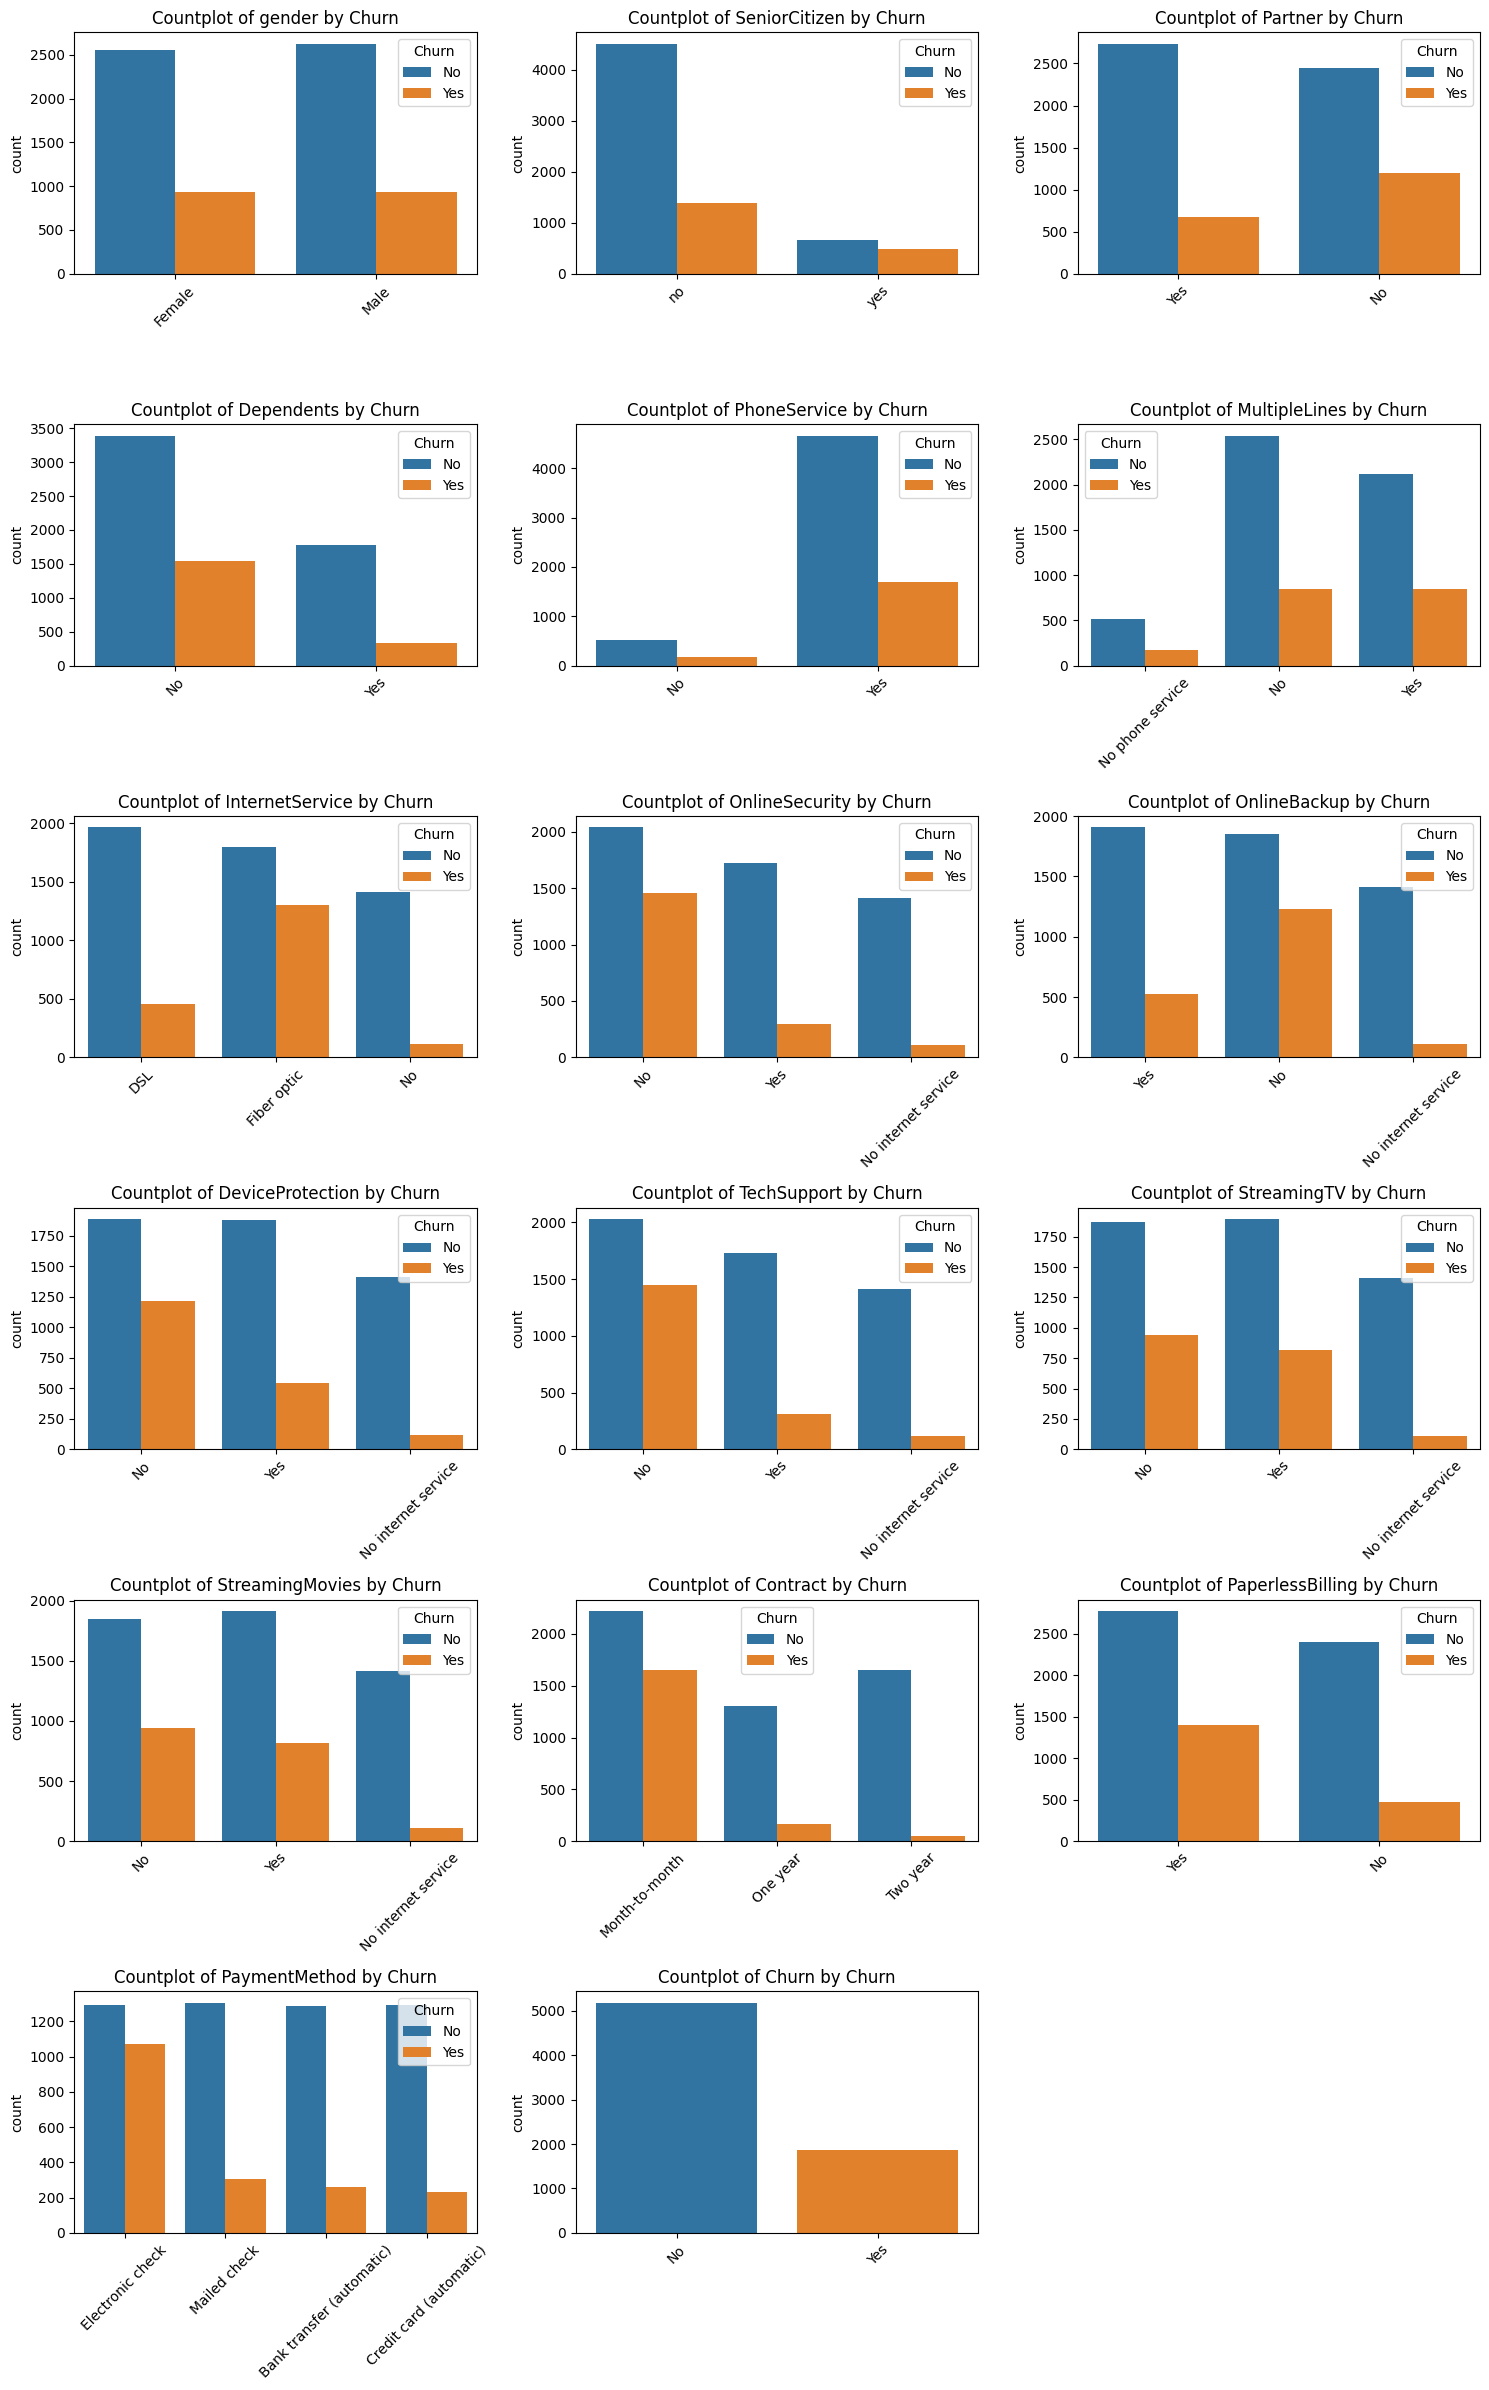

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded and preprocessed
try:
    df = pd.read_csv('/content/churn analysis .csv')
except FileNotFoundError:
    print("Warning: 'churn analysis .csv' not found at /content/. Please ensure it's uploaded or path is correct.")
    if 'df' not in locals() and 'df' not in globals():
        raise FileNotFoundError("DataFrame 'df' not found. Please ensure the 'churn analysis .csv' file is accessible and loaded.")

df['TotalCharges'] = df['TotalCharges'].replace(" ", '0').astype("float")
def conv(value):
  if value==1:
    return "yes"
  else:
    return "no"
df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

# Identify categorical columns suitable for countplots (excluding customerID and numerical columns)
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col != 'customerID']

# Determine grid size for subplots
num_plots = len(categorical_cols)
num_rows = (num_plots + 2) // 3 # Roughly 3 columns per row
num_cols = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        ax = axes[i]
        sns.countplot(x=col, data=df, hue='Churn', ax=ax)
        ax.set_title(f'Countplot of {col} by Churn')
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('') # Hide x-axis label, title is sufficient
        if col == 'gender': # Hide legend for gender if only two categories and Churn is hue
            if 'gender' in ax.get_legend_handles_labels()[1]:
                ax.legend().set_visible(False)

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

those who have services like phone services dont tend to churn


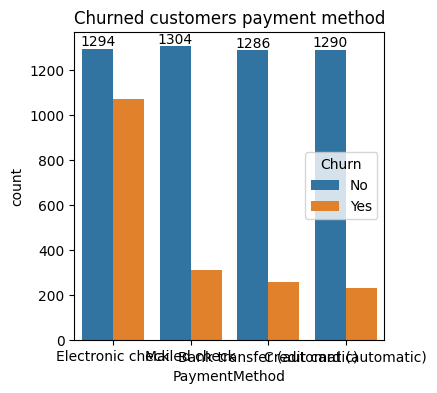

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded and preprocessed
try:
    df = pd.read_csv('/content/churn analysis .csv')
except FileNotFoundError:
    print("Warning: 'churn analysis .csv' not found at /content/. Please ensure it's uploaded or path is correct.")
    # In an interactive session, 'files.upload()' would prompt the user. For this automated context, we assume a previous successful upload or file existence.
    if 'df' not in locals() and 'df' not in globals():
        # Attempt to load from previous definition if not explicitly loaded, though better to load directly
        # For robustness, we will raise an error if df is genuinely not available
        raise FileNotFoundError("DataFrame 'df' not found. Please ensure the 'churn analysis .csv' file is accessible and loaded.")

# Preprocessing steps for df
df['TotalCharges'] = df['TotalCharges'].replace(" ", '0').astype("float")
def conv(value):
  if value==1:
    return "yes"
  else:
    return "no"
df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

plt.figure(figsize=(4,4))
ax=sns.countplot(x="PaymentMethod",data=df,hue='Churn')
ax.bar_label(ax.containers[0])
plt.title("Churned customers payment method")
plt.show()

they are more likely to churn when using electrnics
